In [15]:
print("Практика 16 завершена")
print(f"Місто: {city}")
print(f"Кількість початкових спостережень: {len(climate)}")
print(f"Початковий Пірсон: {pearson_result.statistic:.4f}")
print(f"Початковий Спірмен: {spearman_result.statistic:.4f}")
print(f"Пірсон після викиду: {pearson_anomaly.statistic:.4f}")
print(f"Спірмен після викиду: {spearman_anomaly.statistic:.4f}")


Практика 16 завершена
Місто: Київ
Кількість початкових спостережень: 12
Початковий Пірсон: -0.8598
Початковий Спірмен: -0.8142
Пірсон після викиду: -0.1833
Спірмен після викиду: -0.7417


1. Коефіцієнт Пірсона нормує коваріацію на добуток стандартних відхилень двох змінних. Це робить показник незалежним від одиниць вимірювання. Значення коефіцієнта завжди знаходиться в межах від -1 до 1.

2. Спірмен обчислюється на рангах значень, а не безпосередньо на їх абсолютних величинах. Тому сильна зміна одного або кількох значень має менший вплив на результат, якщо їхній порядок серед інших спостережень залишається подібним.

3. Прикладом може бути залежність y = x². Якщо x симетрично розподілений навколо нуля, звичайна лінійна кореляція Пірсона може бути близькою до нуля, хоча між x та y існує сильний детермінований нелінійний зв'язок.

4. Кореляція не доводить причинність. Дві змінні можуть бути пов'язані через третю змінну, причинний напрямок може бути протилежним, або зв'язок може бути результатом особливостей побудови даних. У цій практиці залежність спеціально закладена у формули генерації даних, тому результат слід трактувати з урахуванням цієї конструкції.


Після додавання аномального спостереження коефіцієнт Пірсона змінюється сильніше, ніж коефіцієнт Спірмена. Пірсон використовує безпосередні числові значення та є чутливим до викидів, особливо якщо вони сильно віддалені від основної хмари точок. Спірмен працює з рангами, тому абсолютна величина викиду має значно менший вплив на результат. Саме тому порівняння двох коефіцієнтів дозволяє побачити вплив аномального спостереження на вимірювання зв'язку.


In [14]:

print("БЕЗ ВИКИДУ:")
print(f"Пірсон:  r = {pearson_result.statistic:.4f}")
print(f"Спірмен: rho = {spearman_result.statistic:.4f}")

print("\nЗ ВИКИДОМ:")
print(f"Пірсон:  r = {pearson_anomaly.statistic:.4f}")
print(f"Спірмен: rho = {spearman_anomaly.statistic:.4f}")

print("\nЗміна:")
print(
    f"Пірсон:  "
    f"{abs(pearson_anomaly.statistic - pearson_result.statistic):.4f}"
)

print(
    f"Спірмен: "
    f"{abs(spearman_anomaly.statistic - spearman_result.statistic):.4f}"
)


БЕЗ ВИКИДУ:
Пірсон:  r = -0.8598
Спірмен: rho = -0.8142

З ВИКИДОМ:
Пірсон:  r = -0.1833
Спірмен: rho = -0.7417

Зміна:
Пірсон:  0.6764
Спірмен: 0.0725


In [13]:
x_anomaly = climate_anomaly["температура"]
y_anomaly = climate_anomaly["витрати_на_опалення"]

pearson_anomaly = pearsonr(x_anomaly, y_anomaly)
spearman_anomaly = spearmanr(x_anomaly, y_anomaly)

print(
    f"Пірсон після викиду: "
    f"r = {pearson_anomaly.statistic:.4f}, "
    f"p-value = {pearson_anomaly.pvalue:.6f}"
)

print(
    f"Спірмен після викиду: "
    f"rho = {spearman_anomaly.statistic:.4f}, "
    f"p-value = {spearman_anomaly.pvalue:.6f}"
)


Пірсон після викиду: r = -0.1833, p-value = 0.548798
Спірмен після викиду: rho = -0.7417, p-value = 0.003707


In [12]:
climate_anomaly = climate.copy()

anomaly = {
    "місто": city,
    "місяць": "Аномальний",
    "температура": 8,
    "опалювальні_дні": 10,
    "витрати_на_опалення": 25.0
}

climate_anomaly.loc[len(climate_anomaly)] = anomaly

climate_anomaly


,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Київ,Січ,-4,23,2.2
1,Київ,Лют,-3,21,3.7
2,Київ,Бер,2,16,1.6
3,Київ,Кві,9,10,0.1
4,Київ,Тра,15,3,0.6
5,Київ,Чер,19,0,0.1
6,Київ,Лип,21,0,0.0
7,Київ,Сер,20,0,0.0
8,Київ,Вер,14,4,0.6
9,Київ,Жов,8,9,0.0


Сильна кореляція між температурою та витратами на опалення сама по собі не є загальним доказом причинності. У цьому навчальному наборі, однак, зв'язок закладений безпосередньо у формулі генерації: спочатку опалювальні дні обчислюються на основі температури, а потім витрати залежать від кількості опалювальних днів. Тому залежність у цьому штучно створеному наборі є результатом заданої конструкції даних. Це відрізняється від ситуації з морозивом і утопленням, де кореляція може виникати через третю змінну, наприклад температуру повітря.


Найсильніший зв'язок слід визначати за абсолютним значенням коефіцієнта кореляції, найближчим до 1. Зв'язок між опалювальними днями та витратами на опалення очікувано є сильним, оскільки витрати безпосередньо генеруються через кількість опалювальних днів. Температура також має сильний негативний зв'язок з обома показниками, оскільки в коді генерації кількість опалювальних днів залежить від температури. Перехід від Пірсона до Спірмена може трохи змінити числові значення, але загальний характер зв'язків для цього набору має залишатися подібним.


In [11]:
pairs = [
    ("температура", "опалювальні_дні"),
    ("температура", "витрати_на_опалення"),
    ("опалювальні_дні", "витрати_на_опалення")
]

for a, b in pairs:
    r = corr_pearson.loc[a, b]
    print(f"{a} — {b}: r = {r:.4f}")


температура — опалювальні_дні: r = -0.9923
температура — витрати_на_опалення: r = -0.8598
опалювальні_дні — витрати_на_опалення: r = 0.8646


In [10]:
corr_spearman = corr_data.corr(method="spearman")

print(corr_spearman.round(3))


                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.984               -0.814
опалювальні_дні           -0.984            1.000                0.826
витрати_на_опалення       -0.814            0.826                1.000


In [9]:
corr_data = climate[
    [
        "температура",
        "опалювальні_дні",
        "витрати_на_опалення"
    ]
]

corr_pearson = corr_data.corr(method="pearson")

print(corr_pearson.round(3))


                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.992               -0.860
опалювальні_дні           -0.992            1.000                0.865
витрати_на_опалення       -0.860            0.865                1.000


Коефіцієнти Пірсона і Спірмена показують негативний зв'язок між температурою та витратами на опалення. Якщо отримані p-value менші за 0.05, нульову гіпотезу про відсутність кореляції відхиляємо для відповідного критерію. Якщо r і rho близькі за значенням, це узгоджується з приблизно монотонним та близьким до лінійного характером зв'язку на діаграмі. 95% довірчий інтервал для r описує діапазон значень генерального коефіцієнта кореляції, який узгоджується з процедурою побудови інтервалу на основі цієї вибірки.


In [8]:
alpha = 0.05

print("Пірсон:")

if pearson_result.pvalue < alpha:
    print("p-value < 0.05 → відхиляємо H0 про нульову кореляцію.")
else:
    print("p-value >= 0.05 → не відхиляємо H0 про нульову кореляцію.")

print("\nСпірмен:")

if spearman_result.pvalue < alpha:
    print("p-value < 0.05 → відхиляємо H0 про нульову кореляцію.")
else:
    print("p-value >= 0.05 → не відхиляємо H0 про нульову кореляцію.")


Пірсон:
p-value < 0.05 → відхиляємо H0 про нульову кореляцію.

Спірмен:
p-value < 0.05 → відхиляємо H0 про нульову кореляцію.


In [7]:
ci = pearson_result.confidence_interval(confidence_level=0.95)

print(f"95% ДІ для коефіцієнта Пірсона:")
print(f"нижня межа = {ci.low:.4f}")
print(f"верхня межа = {ci.high:.4f}")


95% ДІ для коефіцієнта Пірсона:
нижня межа = -0.9600
верхня межа = -0.5643


In [6]:
x = climate["температура"]
y = climate["витрати_на_опалення"]

pearson_result = pearsonr(x, y)
spearman_result = spearmanr(x, y)

print(
    f"Пірсон: r = {pearson_result.statistic:.4f}, "
    f"p-value = {pearson_result.pvalue:.6f}"
)

print(
    f"Спірмен: rho = {spearman_result.statistic:.4f}, "
    f"p-value = {spearman_result.pvalue:.6f}"
)


Пірсон: r = -0.8598, p-value = 0.000336
Спірмен: rho = -0.8142, p-value = 0.001265


На діаграмі розсіювання спостерігається переважно негативний зв'язок: зі зниженням температури витрати на опалення загалом зростають. Хмара точок має приблизно лінійний характер, хоча через випадковий шум окремі точки відхиляються від загального тренду. Явних дуже сильних викидів у початковому наборі немає. Такий напрямок узгоджується з формулою генерації даних, оскільки кількість опалювальних днів збільшується при зниженні температури.


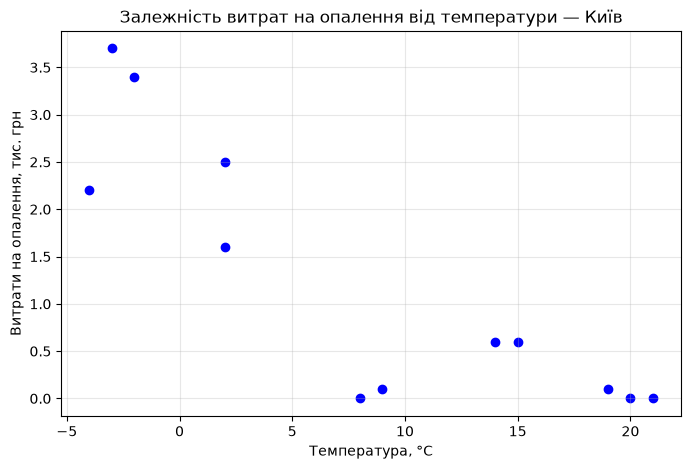

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    climate["температура"],
    climate["витрати_на_опалення"],
    color="blue"
)

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Витрати на опалення, тис. грн")
ax.set_title("Залежність витрат на опалення від температури — Київ")

ax.grid(True, alpha=0.3)

plt.show()


In [4]:
print(climate)
print("\nОпис:")
print(climate.describe())


   місто місяць  температура  опалювальні_дні  витрати_на_опалення
0   Київ    Січ           -4               23                  2.2
1   Київ    Лют           -3               21                  3.7
2   Київ    Бер            2               16                  1.6
3   Київ    Кві            9               10                  0.1
4   Київ    Тра           15                3                  0.6
5   Київ    Чер           19                0                  0.1
6   Київ    Лип           21                0                  0.0
7   Київ    Сер           20                0                  0.0
8   Київ    Вер           14                4                  0.6
9   Київ    Жов            8                9                  0.0
10  Київ    Лис            2               18                  2.5
11  Київ    Гру           -2               19                  3.4

Опис:
       температура  опалювальні_дні  витрати_на_опалення
count    12.000000         12.00000            12.000000
mean    

In [3]:
rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0,
        30
    )

    heating_days = round(heating_days)

    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

climate


,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Київ,Січ,-4,23,2.2
1,Київ,Лют,-3,21,3.7
2,Київ,Бер,2,16,1.6
3,Київ,Кві,9,10,0.1
4,Київ,Тра,15,3,0.6
5,Київ,Чер,19,0,0.1
6,Київ,Лип,21,0,0.0
7,Київ,Сер,20,0,0.0
8,Київ,Вер,14,4,0.6
9,Київ,Жов,8,9,0.0


In [2]:
city = "Київ"

monthly_temp = [
    -4, -3, 2, 9, 15, 19,
    21, 20, 14, 8, 2, -2
]

months = [
    "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
    "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

print("Усі бібліотеки підключено успішно")


Усі бібліотеки підключено успішно


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

np.random.seed(1)


ModuleNotFoundError: No module named 'matplotlib'